In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("station_hour.csv")
df.head()

C:\Users\rajni\AppData\Local\Temp\ipykernel_23000\1677737385.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("station_hour.csv")


,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN


In [3]:
df.shape

(2589083, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   StationId   object 
 1   Datetime    object 
 2   PM2.5       float64
 3   PM10        float64
 4   NO          float64
 5   NO2         float64
 6   NOx         float64
 7   NH3         float64
 8   CO          float64
 9   SO2         float64
 10  O3          float64
 11  Benzene     float64
 12  Toluene     float64
 13  Xylene      float64
 14  AQI         float64
 15  AQI_Bucket  object 
dtypes: float64(13), object(3)
memory usage: 316.1+ MB


In [5]:
df.columns

Index(['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [6]:
df.isnull().sum()

StationId           0
Datetime            0
PM2.5          647689
PM10          1119252
NO             553711
NO2            528973
NOx            490808
NH3           1236618
CO             499302
SO2            742737
O3             725973
Benzene        861579
Toluene       1042366
Xylene        2075104
AQI            570190
AQI_Bucket     570190
dtype: int64

In [7]:
(df.isnull().sum()/len(df))*100

StationId      0.000000
Datetime       0.000000
PM2.5         25.016154
PM10          43.229669
NO            21.386375
NO2           20.430902
NOx           18.956828
NH3           47.762779
CO            19.284897
SO2           28.687261
O3            28.039773
Benzene       33.277380
Toluene       40.260046
Xylene        80.148222
AQI           22.022855
AQI_Bucket    22.022855
dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 16 columns):
 #   Column      Dtype         
---  ------      -----         
 0   StationId   object        
 1   Datetime    datetime64[ns]
 2   PM2.5       float64       
 3   PM10        float64       
 4   NO          float64       
 5   NO2         float64       
 6   NOx         float64       
 7   NH3         float64       
 8   CO          float64       
 9   SO2         float64       
 10  O3          float64       
 11  Benzene     float64       
 12  Toluene     float64       
 13  Xylene      float64       
 14  AQI         float64       
 15  AQI_Bucket  object        
dtypes: datetime64[ns](1), float64(13), object(2)
memory usage: 316.1+ MB


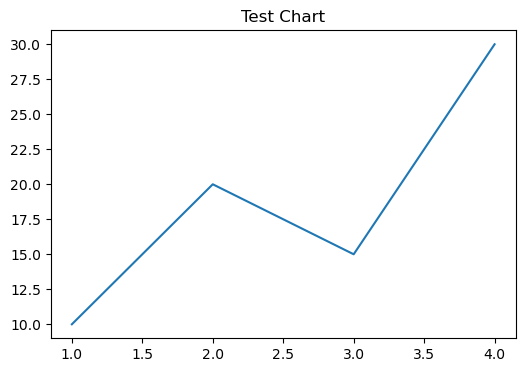

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot([1,2,3,4],[10,20,15,30])
plt.title("Test Chart")
plt.show()

In [23]:
df.columns


Index(['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket',
       'Year', 'Month', 'Day', 'Hour'],
      dtype='object')

In [ ]:
pollutants = ['PM2.5','PM10','NO2','CO','SO2','O3']

for col in pollutants:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_sample = df[pollutants].sample(10000, random_state=42)

df_sample.boxplot(figsize=(12,6))
plt.xticks(rotation=90)
plt.title("Pollutants Outlier Detection")
plt.show()

In [25]:
df[pollutants].isnull().sum()

PM2.5    0
PM10     0
NO2      0
CO       0
SO2      0
O3       0
dtype: int64

In [26]:
df[['PM2.5','PM10','NO2','CO','SO2','O3']].describe()

,PM2.5,PM10,NO2,CO,SO2,O3
count,2.589083e+06,2.589083e+06,2.589083e+06,2.589083e+06,2.589083e+06,2.589083e+06
mean,7.379154e+01,1.402263e+02,3.310250e+01,1.366915e+00,1.100697e+01,3.433085e+01
std,7.844208e+01,1.073830e+02,3.148136e+01,5.660020e+00,1.251437e+01,4.040524e+01
min,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,1.000000e-02
25%,3.550000e+01,1.022500e+02,1.568000e+01,5.000000e-01,5.750000e+00,1.573000e+01
50%,5.259000e+01,1.162500e+02,2.479000e+01,8.000000e-01,8.250000e+00,2.475000e+01
75%,7.775000e+01,1.320000e+02,3.820000e+01,1.200000e+00,1.140000e+01,3.738000e+01
max,1.000000e+03,1.000000e+03,4.999900e+02,4.985700e+02,1.999600e+02,9.970000e+02


<Figure size 1000x500 with 0 Axes>

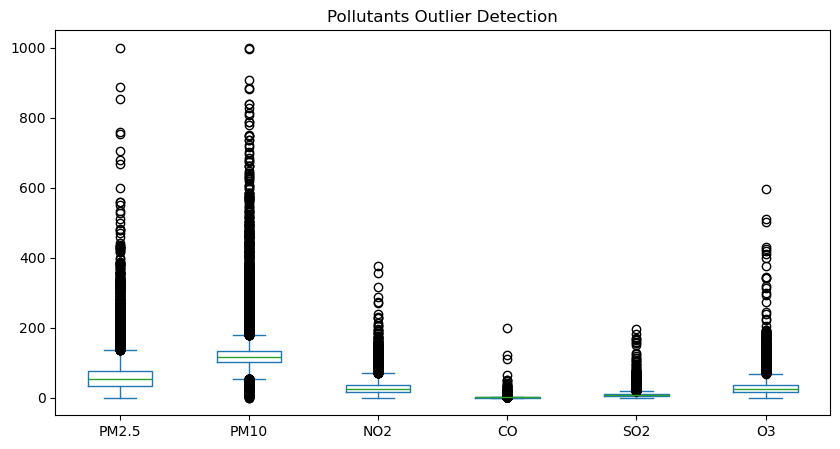

In [27]:
plt.figure(figsize=(10,5))

df[['PM2.5','PM10','NO2','CO','SO2','O3']].sample(5000).plot(
    kind='box',
    figsize=(10,5)
)

plt.title("Pollutants Outlier Detection")
plt.show()

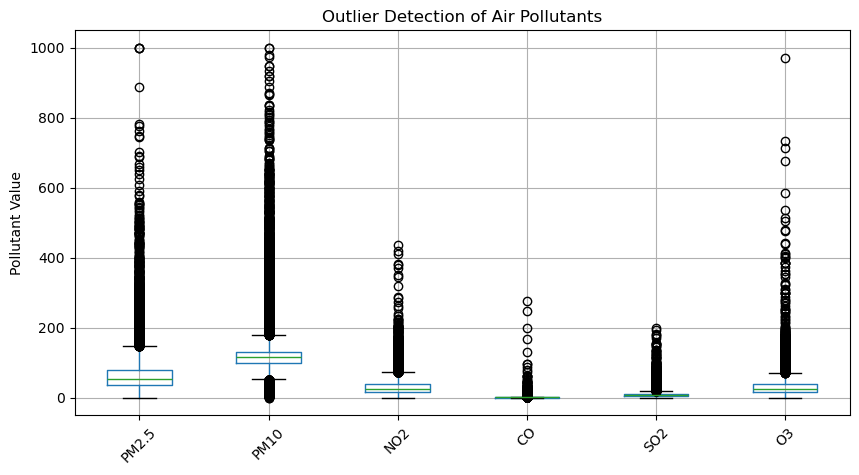

In [28]:
plt.figure(figsize=(10,5))

df_sample[['PM2.5','PM10','NO2','CO','SO2','O3']].boxplot()

plt.title("Outlier Detection of Air Pollutants")
plt.ylabel("Pollutant Value")
plt.xticks(rotation=45)
plt.show()

In [29]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

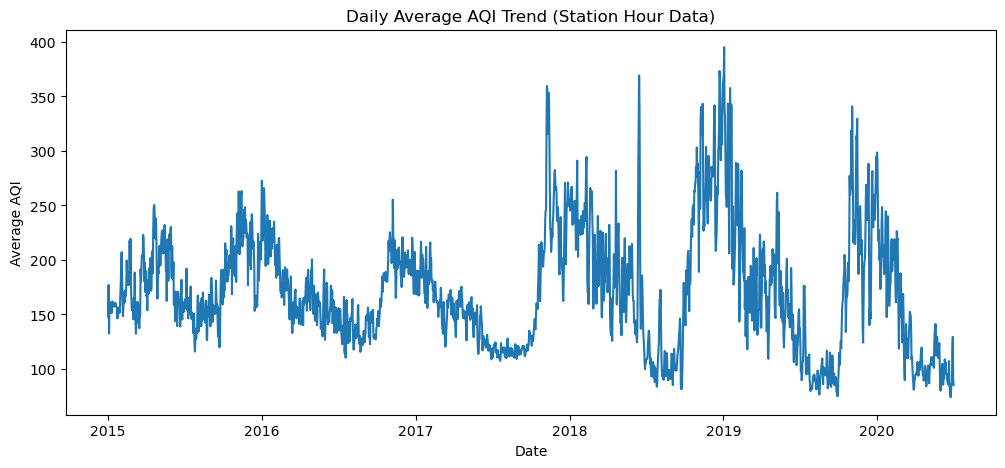

In [30]:
daily_aqi = df.groupby(df['Datetime'].dt.date)['AQI'].mean()

plt.figure(figsize=(12,5))
daily_aqi.plot()

plt.title("Daily Average AQI Trend (Station Hour Data)")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.show()

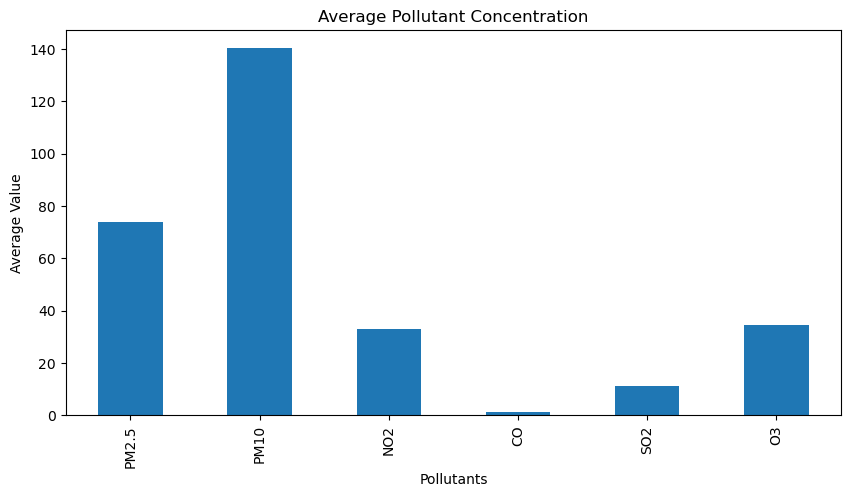

In [31]:
pollutants = ['PM2.5','PM10','NO2','CO','SO2','O3']

avg_pollutants = df[pollutants].mean()

plt.figure(figsize=(10,5))
avg_pollutants.plot(kind='bar')

plt.title("Average Pollutant Concentration")
plt.xlabel("Pollutants")
plt.ylabel("Average Value")
plt.show()

In [33]:
def aqi_category(x):
    if x <= 50:
        return "Good"
    elif x <= 100:
        return "Satisfactory"
    elif x <= 200:
        return "Moderate"
    elif x <= 300:
        return "Poor"
    elif x <= 400:
        return "Very Poor"
    else:
        return "Severe"

df['AQI_Category'] = df['AQI'].apply(aqi_category)

In [34]:
df['AQI_Category'].value_counts()

AQI_Category
Moderate        1245198
Satisfactory     530164
Very Poor        301150
Poor             239990
Good             152113
Severe           120468
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

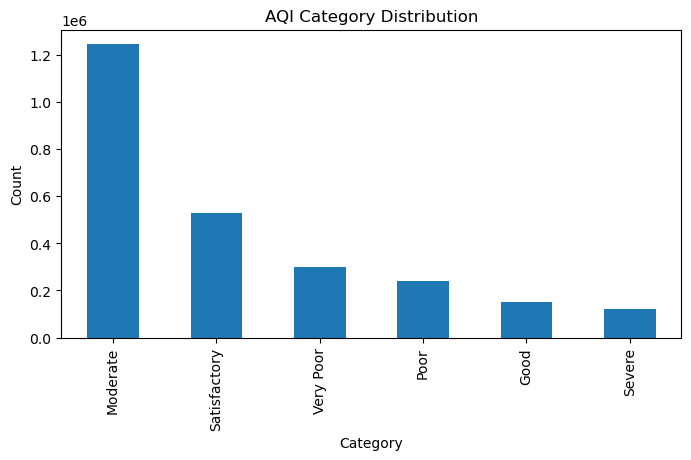

In [35]:
df['AQI_Category'].value_counts().plot(kind='bar', figsize=(8,4))

plt.title("AQI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show

In [41]:
station_aqi = df.groupby('StationId')['AQI'].mean().sort_values(ascending=False)

station_aqi.head(10)

StationId
GJ001    337.950137
DL002    308.406115
DL038    269.638166
DL020    266.089884
DL010    259.912287
DL015    259.685418
DL028    251.508153
DL032    251.193290
DL005    250.969634
UP016    248.545518
Name: AQI, dtype: float64

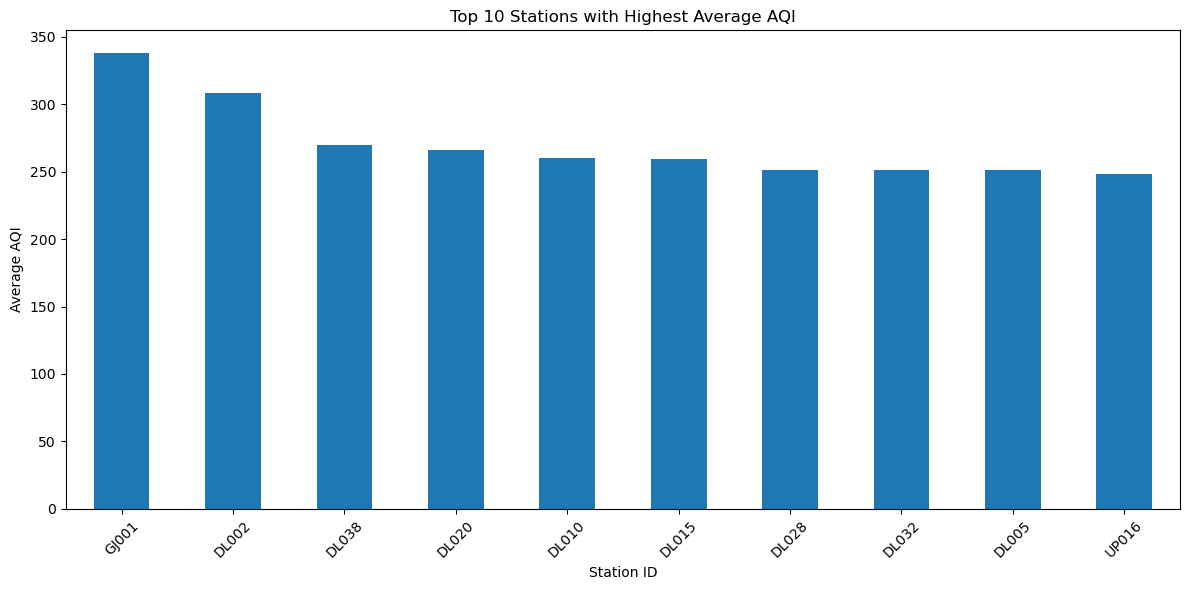

In [42]:
plt.figure(figsize=(12,6))

station_aqi.head(10).plot(kind='bar')

plt.title("Top 10 Stations with Highest Average AQI")
plt.xlabel("Station ID")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
import pandas as pd

df = pd.read_csv("Station_hour.csv")

df.head()

C:\Users\rajni\AppData\Local\Temp\ipykernel_23000\2101007312.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Station_hour.csv")


,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN


In [51]:
df.shape

(2589083, 16)

In [52]:
df.to_csv("Clean_Station_hour_final.csv", index=False)

In [53]:
import os
os.listdir()

['.anaconda',
 '.conda',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.python_history',
 '.virtual_documents',
 'anaconda2026',
 'anaconda2026new',
 'anaconda3',
 'AppData',
 'Application Data',
 'CC General.csv.zip',
 'city_day.csv',
 'City_Day_Air_Quality_Analysis.ipynb',
 'city_hour.csv',
 'City_Hour_Analysis.ipynb',
 'Cleaned_Air_Quality_Data.csv',
 'Cleaned_City_Hour_Data.csv',
 'Clean_Station_hour_final.csv',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'Favorites',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{c58467e3-8bf5-11f0-ba04-c12705c7047f}.TM.blf',
 'NTUSER.DAT{c58467e3-8bf5-11f0-ba04-c12705c7047f}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{c58467e3-8bf5-11f0-ba04-c12705c7047f}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'practice.ipynb',
 'Pr